**Conjoint Analysis Quiz**
*BUMK744 Marketing Research and Analytics*

**Notes**
- Save your notebook often, in case you get disconnected or the Google Colab environment crashes.
- Save a copy of your notebook.
- You **need to submit** your notebook along with your canvas quiz.

In this question, you will conduct a conjoint analysis on credit cards. An online retailer considers offering a new credit card to its customers. You, as a marketing analyst, are given the task to conduct a study on preferences of its customers for credit cards.

To address these issues, your team conducted a full profile conjoint study using a sample of the online retailer's customer database. An online survey was developed, consisting of full profiles. The most important attributes and levels were identified based on a focus group discussion and expert options. The data file is “CreditCard Data.xlsx.”

The following attributes and levels were identified and used in the study:



*   **Attribute** （**Levels**）
*  Brand（Mastercard, Visa, Discover）
*  Fee	（0 fee, 10 fee, 25 fee）
*  Interest (intro APR)	（0% interest, 15% interest）
*  Cash back （no cash back, 1% cash back）
*  Credit limit（1,000, 3,000, 10,000）


A random sample of 5 customers who were drawn from the customer database were contacted and took the survey by e-mail.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

url = 'https://raw.githubusercontent.com/XinyingHao/BUMK744/refs/heads/main/CreditCard%20Data.csv'
data = pd.read_csv(url)


data.head()

,Profile,Brand_Visa,Brand_Discover,Fee_$10 fee,Fee_$0 fee,Interest_0% interest,Cashback_no cash back,CreditLimit_$10000 credit limit,CreditLimit_$1000 credit limit,Customer 1 Rating,Customer 2 Rating,Customer 3 Rating,Customer 4 Rating,Customer 5 Rating
0,1,1,0,0,1,0,0,0,0,6,6,4,5,5
1,2,0,1,0,1,0,0,0,0,5,5,3,3,5
2,3,0,0,1,0,0,1,1,0,2,3,2,4,1
3,4,0,1,0,1,0,1,1,0,4,4,2,4,3
4,5,0,1,0,0,0,0,0,1,4,4,6,4,5


# Quiz:
- **Important: Do not center or standardize the data yourself**. Use the provided **`X`** variable as-is
- Provide answers to the following questions on Canvas

# Question 1

In this credit card design problem, how many **possible product profiles/combinations** should you create in full profile conjoint analysis?  

**Note:** Your answer should be **an integer**, i.e., a whole number without a fractional component.


# Question 2
For the brand attribute, using Mastercard as the baseline (with a partworth of 0) in the table below, what are the partworths of the Visa card for Customer 1?

**`Note`**: Round your answer to two decimal places. For example, if your answer is 12.345, provide 12.35

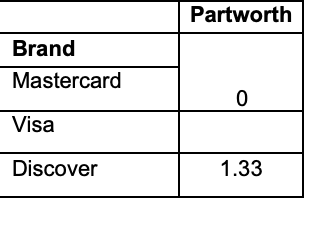

In [ ]:
import statsmodels.api as sm
from statsmodels.api import add_constant

plt.style.use('bmh')


X = data.iloc[:,1:9]
X = add_constant(X)
y = data['Customer 1 Rating']

# Question 3

**Question**:

Based on the Parworth plot, what is **the best configuration** (credit card with highest preference/utility) for **customer 1**?

Choose from:

*  Mastercard, 25 fee, 15% interest, 1% cash back, 1000 credit limit
*  Visa, 25 fee, 15% interest, no cash back, 3000 credit limit
*  Discover, 10 fee, 0% interest, no cash back, 10000 credit limit
*  Visa, 0 fee, 0% interest, 1% cashback, 10000 credit limit





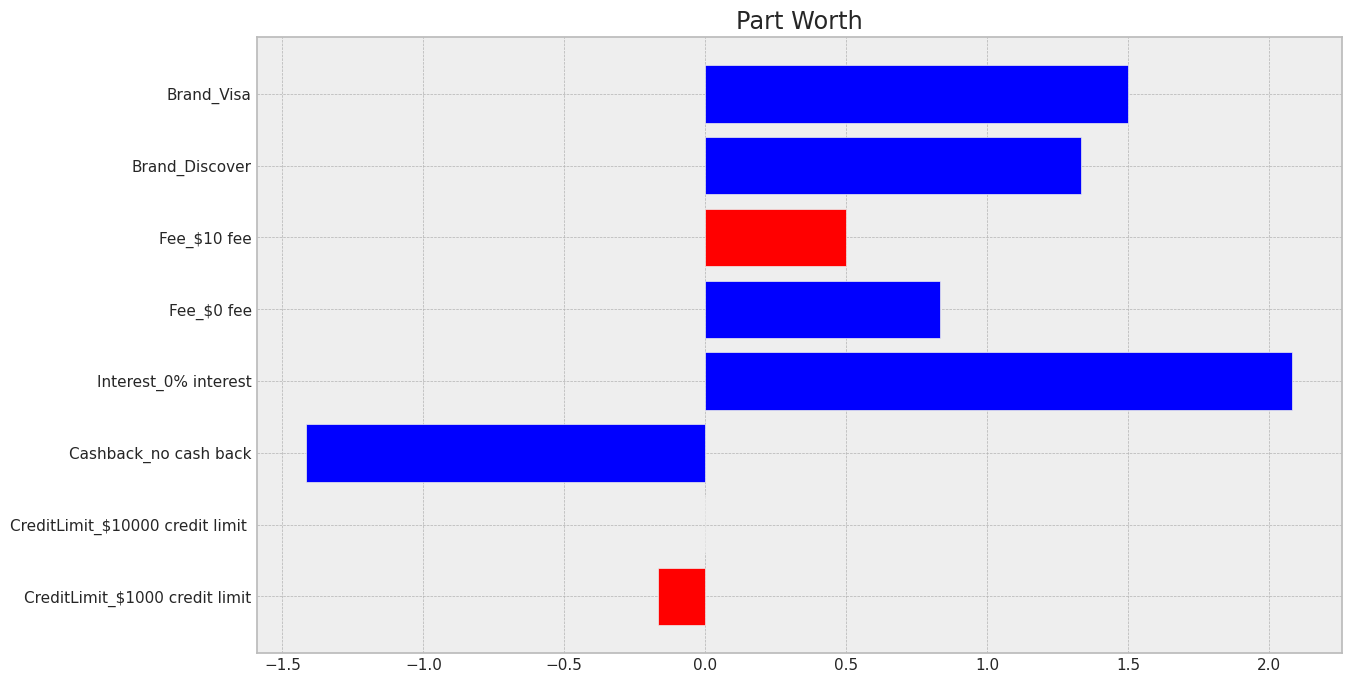

In [ ]:
df_res1 = pd.DataFrame({
    'param_name': res1.params.keys()
    , 'param_w': res1.params.values
    , 'pval': res1.pvalues
})

# deleting constant
df_res1 = df_res1[1:]

# adding field for absolute of parameters
df_res1['abs_param_w'] = np.abs(df_res1['param_w'])

# marking field is significant under 95% confidence interval
df_res1['is_sig_95'] = (df_res1['pval'] < 0.05)

# constructing color naming for each param
df_res1['c'] = ['blue' if x else 'red' for x in df_res1['is_sig_95']]



f, ax = plt.subplots(figsize=(14, 8))
plt.title('Part Worth')
pwu = df_res1['param_w']
xbar = np.arange(len(pwu))
plt.barh(xbar, pwu, color=df_res1['c'])
plt.yticks(xbar, labels=df_res1['param_name'])
ax.invert_yaxis()
plt.show()

# Question 4



In [ ]:
# need to assemble per attribute for every level of that attribute in dicionary
range_per_feature = dict()
for key, coeff in res1.params[1:].items():
    sk =  key.split('_')
    feature = sk[0]
    if len(sk) == 1:
        feature = key
    if feature not in range_per_feature:
        range_per_feature[feature] = list()

    range_per_feature[feature].append(coeff)

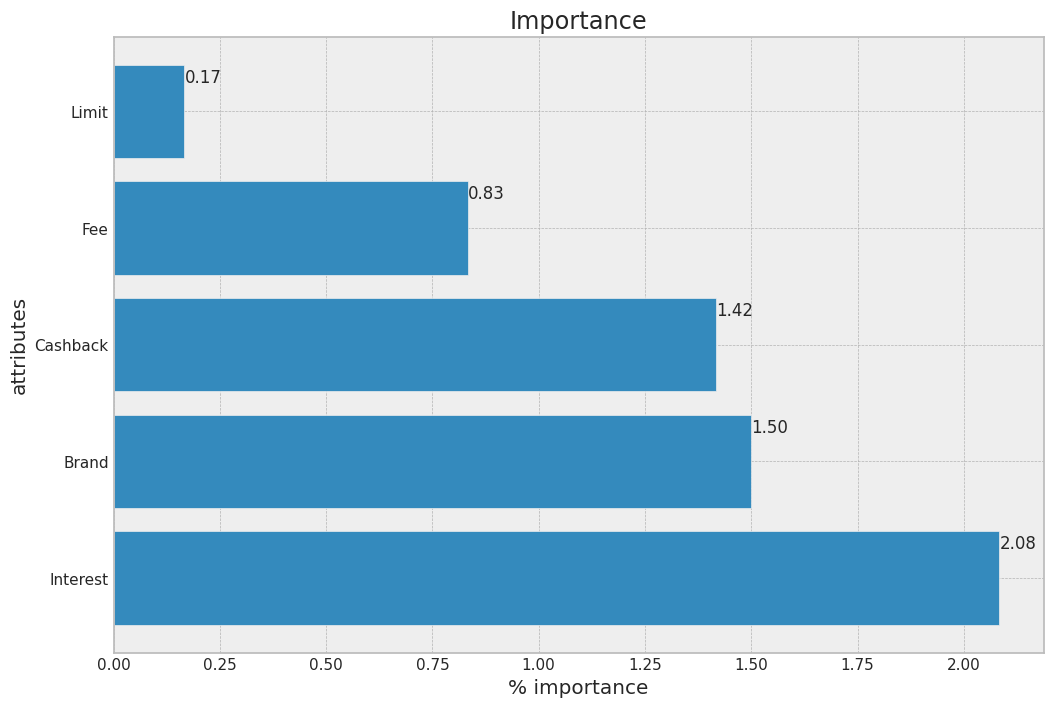

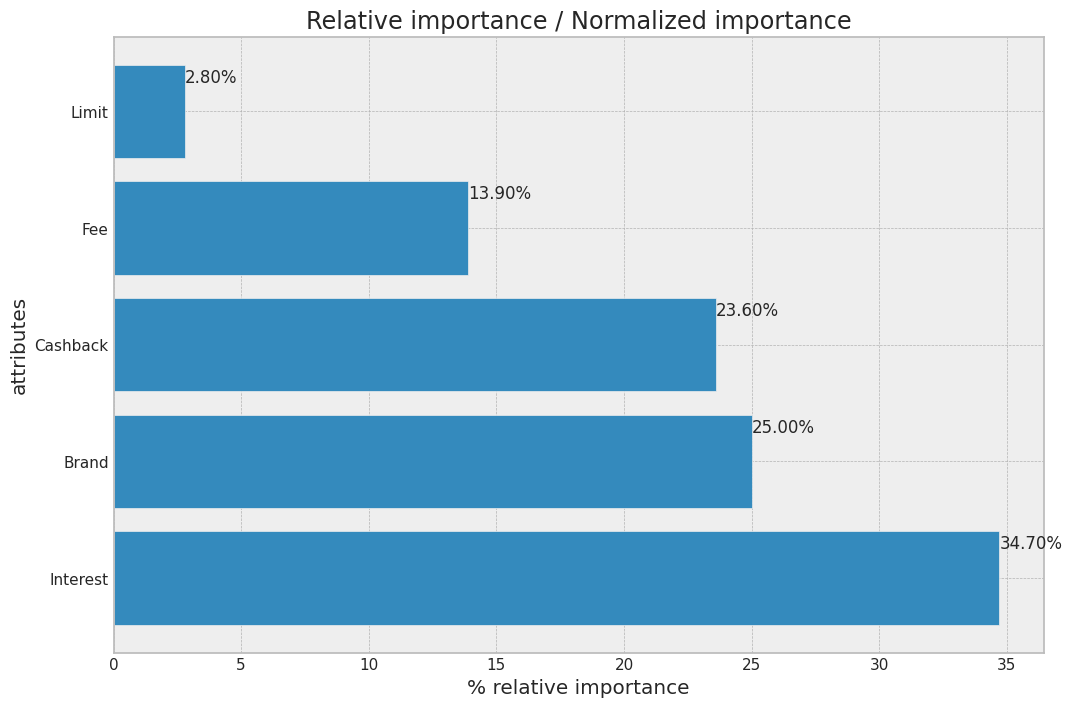

In [ ]:
# importance per feature is range of coef in a feature
# while range is simply max(x) - min(x)
importance_per_feature = {
    k: max(max(v),0) - min(min(v),0) for k, v in range_per_feature.items()
}

# compute relative importance per feature
# or normalized feature importance by dividing
# sum of importance for all features
total_feature_importance = sum(importance_per_feature.values())
relative_importance_per_feature = {
    k: 100 * round(v/total_feature_importance, 3) for k, v in importance_per_feature.items()
}

alt_data = pd.DataFrame(
    list(importance_per_feature.items()),
    columns=['attr', 'importance']
).sort_values(by='importance', ascending=False)


f, ax = plt.subplots(figsize=(12, 8))
xbar = np.arange(len(alt_data['attr']))
plt.title('Importance')
plt.barh(xbar, alt_data['importance'])
for i, v in enumerate(alt_data['importance']):
    ax.text(v , i + .25, '{:.2f}'.format(v))
plt.ylabel('attributes')
plt.xlabel('% importance')
plt.yticks(xbar, alt_data['attr'])
plt.show()

alt_data = pd.DataFrame(
    list(relative_importance_per_feature.items()),
    columns=['attr', 'relative_importance (pct)']
).sort_values(by='relative_importance (pct)', ascending=False)


f, ax = plt.subplots(figsize=(12, 8))
xbar = np.arange(len(alt_data['attr']))
plt.title('Relative importance / Normalized importance')
plt.barh(xbar, alt_data['relative_importance (pct)'])
for i, v in enumerate(alt_data['relative_importance (pct)']):
    ax.text(v , i + .25, '{:.2f}%'.format(v))
plt.ylabel('attributes')
plt.xlabel('% relative importance')
plt.yticks(xbar, alt_data['attr'])
plt.show()

Based on the relative importance plot above, what is the **relative importance of brand**?

**`Note`**: Your answer should be two decimal places.

# Question 5

Based on the relative importance plot above for **customer 1**, what is the relative importance of brand, what is **the most important attribute**?

Choose from:

*   Interest
*   Brand
*   Fee
*   Credit Limit



# Question 7

Given the calculated preference for the five customers, what is the **market share of Credit Card A**? **Note:** If there is a tie, each restaurant gains 0.5 customer.

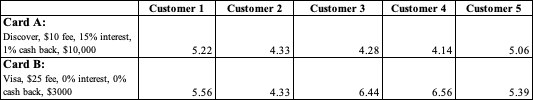

# Question 8

Based on the conjoint analysis, the retailer decided to offer a new credit card: **Visa, 10 fee, 0% interest, no cash back, 3000 credit limit**, with an upgrade option for the one with 1% cashback.

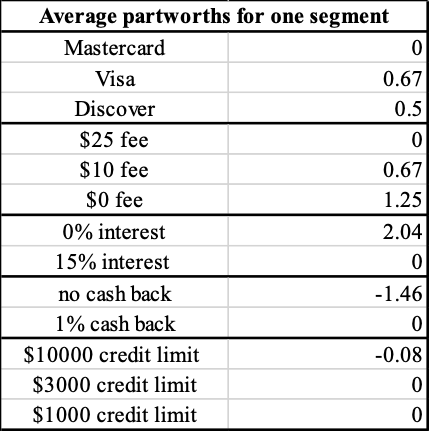

For this segment, if the change in preference from 10 fee to 25 is 0.67 rating points, and the change in preference from no cash back to 1% cash back is 1.46 rating points. Now Your current product, with no cash back, charges for 10 fee. What should you charge to an upgrade from no cash back to 1% cash back?

**`Note`**: Round your answer to two decimal places. For example, if your answer is 12.345, provide 12.35